# Grid-Connected Tidal Energy Case Study

This case study demonstrates a representative grid-connected tidal energy workflow using VITAL.

The example compares candidate tidal sites and system assumptions using:

- tidal resource data,
- rotor performance data,
- vessel/platform assumptions,
- rotor simulation,
- constraint checks,
- LCOE calculations,
- and design optimization.

For grid-connected applications, site characteristics such as tidal resource strength, mooring depth, and estimated cable length can affect feasibility and cost.

The workflow is intended for early-stage screening. Results depend on the selected input data, cost assumptions, and optimization bounds, and should not be interpreted as final design recommendations.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib3.exceptions import InsecureRequestWarning

from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation
from vital.module_vessel import VesselData
from vital.module_constraint_checker import ConstraintChecker
from vital.module_lcoe import LCOEData, LCOECalculator
from vital.module_lcoe_optimizer import LCOEOptimizer

warnings.simplefilter("ignore", InsecureRequestWarning)

plt.style.use("tableau-colorblind10")

## 1. Baseline design assumptions

To keep the comparison clear, we start with a fixed baseline design.

The baseline design includes:

- rotor size,
- rated power,
- hub depth,
- drivetrain settings,
- vessel/platform geometry,
- and cost assumptions.

These values are representative inputs for a screening-level case study and should not be interpreted as final HDPS design parameters.

Later, we will compare this baseline design across multiple sites and then test whether the design can be improved through optimization.

In [2]:
# Baseline turbine and drivetrain configuration
config = {
    # Turbine geometry and ratings
    "Radius": 3.0,             # Rotor radius (m)
    "Prated": 150000.0,        # Rated electrical power per turbine (W)
    "Trated": 10000.0,         # Rated generator torque (N m)
    "dHub": 5.0,               # Hub depth below free surface (m)
    "number_of_turbines": 4,   # Number of turbines in the system

    # Drivetrain and generator parameters
    "Ng": 5.0,                 # Gear ratio
    "J_d": 50.0,               # Drivetrain inertia
    "B_d": 1.0,                # Drivetrain damping/friction
    "J_r": 300.0,              # Rotor inertia
    "power_model": "simple",   # Built-in generator electrical model
    "Kt": 20.0,                # Generator torque constant
    "Rw": 0.1,                 # Generator winding resistance
}

# Representative vessel / support platform assumptions.
# These dimensions are in meters and are roughly representative of a large
# container ship scale. They are used here to define representative support-body
# area and displaced-volume estimates for a screening-level case study.
length_m = 366.0
beam_m = 51.0
draft_m = 15.5
block_coefficient = 0.65

# Simplified projected frontal area used for drag calculations.
projected_area_m2 = beam_m * draft_m

# Approximate displaced volume using a block-coefficient estimate.
vessel_volume_m3 = length_m * beam_m * draft_m * block_coefficient

# Representative vessel/platform properties used by the pitch constraint.
vessel_properties = {
    "Xm": 10.0,                       # Horizontal force-application distance (m)
    "Zm": 5.0,                        # Vertical force-application distance (m)
    "Kphi": 1.0e12,                   # Representative pitch hydrostatic stiffness (N m/rad)
    "theta": np.deg2rad(45.0),        # Mooring line angle (rad)
    "phi": np.deg2rad(5.0),           # Representative pitch angle (rad)
    "area": projected_area_m2,        # Cross-sectional/projected area (m^2)
    "Cd": 0.9,                        # Drag coefficient
}

print("Baseline turbine configuration:")
print(f"  Rotor radius: {config['Radius']:.2f} m")
print(f"  Rated power per turbine: {config['Prated'] / 1000:.1f} kW")
print(f"  Number of turbines: {config['number_of_turbines']}")
print(f"  Total rated power: {config['Prated'] * config['number_of_turbines'] / 1000:.1f} kW")

print()
print("Representative container-ship-scale support body:")
print(f"  Length: {length_m:.1f} m")
print(f"  Beam: {beam_m:.1f} m")
print(f"  Draft: {draft_m:.1f} m")
print(f"  Block coefficient: {block_coefficient:.2f}")
print(f"  Projected area: {projected_area_m2:.1f} m^2")
print(f"  Approximate displaced volume: {vessel_volume_m3:,.0f} m^3")

Baseline turbine configuration:
  Rotor radius: 3.00 m
  Rated power per turbine: 150.0 kW
  Number of turbines: 4
  Total rated power: 600.0 kW

Representative container-ship-scale support body:
  Length: 366.0 m
  Beam: 51.0 m
  Draft: 15.5 m
  Block coefficient: 0.65
  Projected area: 790.5 m^2
  Approximate displaced volume: 188,060 m^3


## 2. Load rotor performance data

The rotor performance data defines how the turbine behaves as flow conditions change.

The rotor file provides:

- ``TSR``: tip-speed ratio
- ``Ct``: thrust coefficient, which indicates the hydrodynamic load the rotor places on the system
- ``Cq``: torque coefficient, which indicates the torque required or produced by the rotor

VITAL computes the power coefficient internally as:

$$
C_p = TSR \cdot C_q
$$

These curves are used by the simulation to estimate power production and loading.

This HDPS case study also loads optional ``Cpmin`` data for the cavitation constraint.

After loading the rotor data, we add the rotor-specific coefficient functions and operating points to the baseline configuration so ``RotorSimulation`` can use them.

The plot below shows how the rotor coefficients vary with tip-speed ratio over the measured TSR range. This helps identify where the turbine performs best and avoids emphasizing extrapolated behavior outside the supplied rotor data.

Optimal Cp: 0.436
Optimal TSR: 3.917
Estimated TSRmax: 16.468
Measured TSR range: 1.962 to 6.468


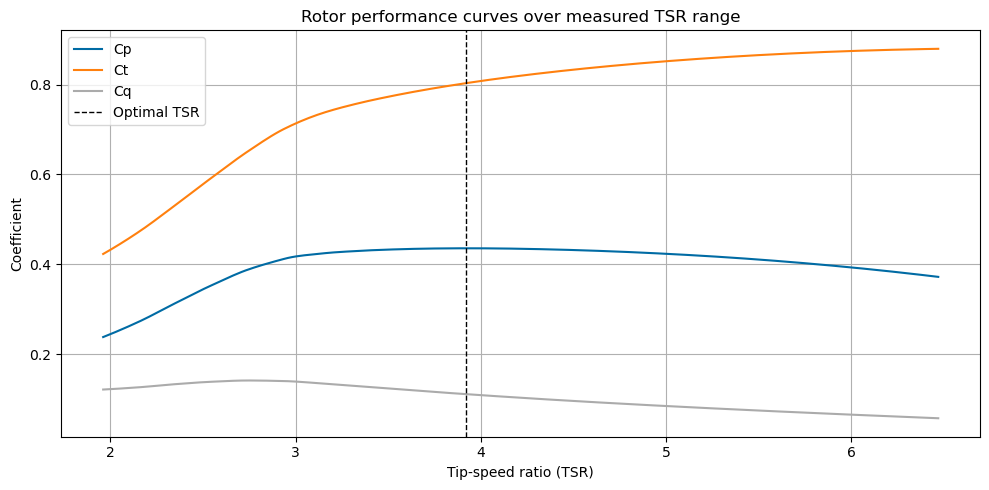

In [3]:
rotor = RotorData(
    filename="../data/Sandia_rotor_data.txt",
    cpmin_filename="../data/Cpmin_data.json",
)

print(f"Optimal Cp: {rotor.CpOpt:.3f}")
print(f"Optimal TSR: {rotor.TSROpt:.3f}")
print(f"Estimated TSRmax: {rotor.TSRmax:.3f}")
print(f"Measured TSR range: {rotor.tsr.min():.3f} to {rotor.tsr.max():.3f}")

# Add rotor-specific coefficient functions and operating points to the config.
config["CpFunc"] = rotor.get_cp
config["CqFunc"] = rotor.get_cq
config["CtFunc"] = rotor.get_ct
config["CpOpt"] = rotor.CpOpt
config["TSROpt"] = rotor.TSROpt
config["TSRmax"] = rotor.TSRmax

# Plot over the measured TSR range to avoid emphasizing extrapolated behavior.
tsr_values = np.linspace(rotor.tsr.min(), rotor.tsr.max(), 200)

cp_values = rotor.get_cp(tsr_values)
ct_values = rotor.get_ct(tsr_values)
cq_values = rotor.get_cq(tsr_values)

plt.figure(figsize=(10, 5))
plt.plot(tsr_values, cp_values, label="Cp")
plt.plot(tsr_values, ct_values, label="Ct")
plt.plot(tsr_values, cq_values, label="Cq")
plt.axvline(rotor.TSROpt, color="k", linestyle="--", linewidth=1, label="Optimal TSR")
plt.xlabel("Tip-speed ratio (TSR)")
plt.ylabel("Coefficient")
plt.title("Rotor performance curves over measured TSR range")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Load and inspect the tidal resource

We now choose candidate tidal sites and inspect their tidal resources.

For this public-facing case study, we compare three NOAA current stations:

- ``COI1210``
- ``COI0306``
- ``COI0303``

Each site has different tidal conditions and deployment characteristics, so the best design may differ from site to site. Flow speed, mooring depth, and cable length can all affect feasibility and LCOE.

This case study retrieves tidal data directly from NOAA. For offline or fully reproducible documentation builds, use the local-file workflow from the tidal-data tutorial or configure notebook execution accordingly.

In [4]:
startdate = "2020-01-01"
range_hrs = 14 * 24

# Use hourly data for documentation/runtime practicality.
# For higher-fidelity studies, reduce this value after confirming runtime.
time_step_s = 3600

sites = ["COI1210", "COI0306", "COI0303"]

## 4. Site comparison: baseline design at each site

A key question in tidal energy planning is whether one site is better than another.

Here we keep the design fixed and compare sites to see how resource quality, depth, and cable length affect performance and feasibility.

This section evaluates the same baseline turbine and support-body assumptions at each site. Site-specific optimization is performed later in the case study.

In [5]:
site_summary = []

for site in sites:
    print(f"Evaluating baseline design at site {site}...")

    tidal_site = process_tidal_data(
        station=site,
        startdate=startdate,
        range_hrs=range_hrs,
        time_step_s=time_step_s,
        city_data_file="../data/AlaskaCityLatLong.txt",
    )

    config_site = config.copy()
    config_site["dMoor"] = tidal_site.mooring_distance
    config_site["Uinf"] = tidal_site.flow_speeds
    config_site["t"] = tidal_site.times

    rotor_sim = RotorSimulation(config_site)
    rotor_sim.simulate()
    sim_site = rotor_sim.get_results()

    vessel_site = VesselData(
        user_defined=True,
        vessel_properties=vessel_properties,
        simResult=sim_site,
    )

    checker_site = ConstraintChecker(rotor, config_site, vessel_site, sim_site)

    constraint_results = {
        "Power": checker_site.check_power_constraint(),
        "Depth": checker_site.check_depth_constraint(),
        "Cavitation": checker_site.check_cavitation_constraint(),
        "Pitch": checker_site.check_pitch_constraint(),
    }

    # Constraint margins provide more detail than pass/fail flags.
    power_margin_min = np.min(checker_site.power_constraint())
    depth_margin = checker_site.depth_constraint()
    cavitation_margin_min = np.min(checker_site.cavitation_constraint())
    pitch_margin_min = np.min(checker_site.pitch_constraint())

    feasible = all(constraint_results.values())

    if feasible:
        lcoe_data_site = LCOEData(
            tidalData=tidal_site,
            turbineConfig=config_site,
            vesselData=vessel_site,
            simResult=sim_site,
            lifetime=20,
            discount_rate=0.08,
            turbulence_intensity=0.0,
            customer="customer_A",
            application="grid_connection",
        )
        calc_site = LCOECalculator(lcoe_data_site)
        lcoe_site = calc_site.calculate_lcoe()
        annual_energy_site = calc_site.calculate_annual_energy()
    else:
        lcoe_site = np.nan
        annual_energy_site = np.nan

    site_summary.append(
        {
            "Site": site,
            "Station name": tidal_site.station_name,
            "Nearest city": tidal_site.nearest_city,
            "Mooring depth (m)": tidal_site.mooring_distance,
            "Cable length (m)": tidal_site.cable_length,
            "Mean flow speed (m/s)": np.mean(tidal_site.flow_speeds),
            "Max flow speed (m/s)": np.max(tidal_site.flow_speeds),
            "Annual energy (kWh)": annual_energy_site,
            "LCOE ($/kWh)": lcoe_site,
            "Feasible": feasible,
            "Power ok": constraint_results["Power"],
            "Depth ok": constraint_results["Depth"],
            "Cavitation ok": constraint_results["Cavitation"],
            "Pitch ok": constraint_results["Pitch"],
            "Min power margin (W)": power_margin_min,
            "Depth margin (m)": depth_margin,
            "Min cavitation margin (Pa)": cavitation_margin_min,
            "Min pitch margin (N m)": pitch_margin_min,
        }
    )

site_df = pd.DataFrame(site_summary)
site_df

Evaluating baseline design at site COI1210...
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Evaluating baseline design at site COI0306...
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.
Evaluating baseline design at site COI0303...
Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.


,Site,Station name,Nearest city,Mooring depth (m),Cable length (m),Mean flow speed (m/s),Max flow speed (m/s),Annual energy (kWh),LCOE ($/kWh),Feasible,Power ok,Depth ok,Cavitation ok,Pitch ok,Min power margin (W),Depth margin (m),Min cavitation margin (Pa),Min pitch margin (N m)
0,COI1210,"Middle Ground Shoal, E of.",Anchorage,43.3,80705.88,1.261713,2.98247,740024.180212,1.422268,True,True,True,True,True,3854.591308,2.0,61100.155389,8.722179e+10
1,COI0306,"Fire Island Shoal, NW of",Anchorage,23.8,36233.40,1.127994,2.72852,578326.213551,0.860443,True,True,True,True,True,37685.262932,2.0,70644.609565,8.722908e+10
2,COI0303,"Port Mackenzie, South of",Anchorage,31.1,3970.22,1.096303,2.84653,588268.178956,0.164923,True,True,True,True,True,20638.998641,2.0,65778.578850,8.722576e+10


### Interpretation

The sites differ in both resource quality and deployment conditions. Although higher flow can improve energy capture, longer cable lengths and other site-specific factors can increase cost.

The best site is therefore not determined by flow speed alone. Feasibility also depends on the constraint checks and margins, including power limits, rotor submergence, cavitation, and pitch stability.

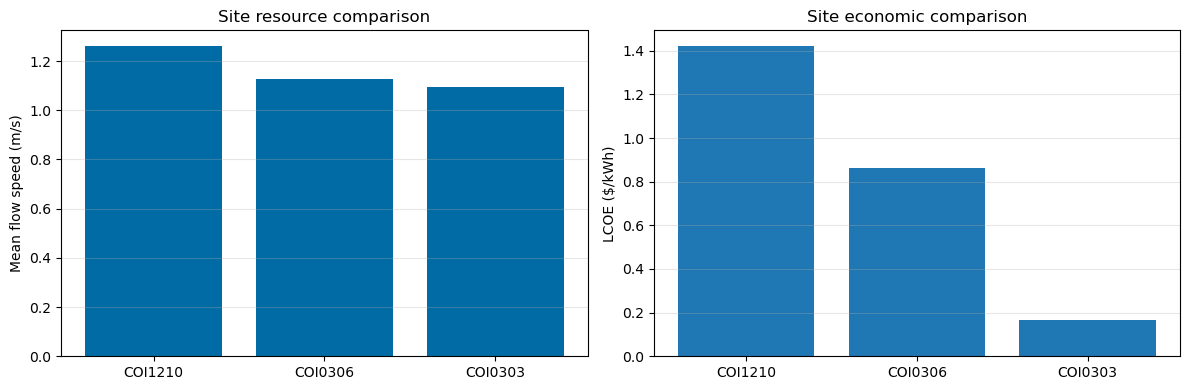

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Site resource comparison
axs[0].bar(site_df["Site"], site_df["Mean flow speed (m/s)"])
axs[0].set_ylabel("Mean flow speed (m/s)")
axs[0].set_title("Site resource comparison")
axs[0].grid(True, axis="y", alpha=0.3)

# Site economic comparison
bar_colors = site_df["Feasible"].map({True: "tab:blue", False: "tab:gray"})

axs[1].bar(site_df["Site"], site_df["LCOE ($/kWh)"], color=bar_colors)
axs[1].set_ylabel("LCOE ($/kWh)")
axs[1].set_title("Site economic comparison")
axs[1].grid(True, axis="y", alpha=0.3)

# Label infeasible sites if any
for idx, row in site_df.iterrows():
    if not row["Feasible"]:
        axs[1].text(
            idx,
            0,
            "Infeasible",
            ha="center",
            va="bottom",
            rotation=90,
            color="tab:red",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## 5. Optimization across all three sites

Finally, we repeat the optimization process for all three candidate sites.

This lets us compare how the best design changes with site conditions.

For each site, the optimizer uses that site's tidal resource, mooring depth, cable length, and time series. This comparison highlights that tidal resource quality, deployment depth, and cable length all influence whether a site is attractive for a grid-connected project.

In [7]:
optimization_bounds = {
    "Radius": (2.0, 4.0, 1.0),               # 2.0, 3.0, 4.0 m
    "Prated": (100000.0, 200000.0, 50000.0), # 100, 150, 200 kW
    "dHub": (3.0, 7.0, 2.0),                 # 3.0, 5.0, 7.0 m
    "number_of_turbines": (2, 6, 2),         # 2, 4, 6
}

num_grid_points = 1
for low, high, step in optimization_bounds.values():
    values = np.arange(low, high + 0.5 * step, step)
    num_grid_points *= len(values)

print(f"Number of design points per site: {num_grid_points}")

Number of design points per site: 81


In [ ]:
import contextlib
import io

site_opt_summary = []

for site in sites:
    print(f"\n=== Optimizing site: {site} ===")

    tidal_site = process_tidal_data(
        station=site,
        startdate=startdate,
        range_hrs=range_hrs,
        time_step_s=time_step_s,
        city_data_file="../data/AlaskaCityLatLong.txt",
    )

    config_site = config.copy()
    config_site["dMoor"] = tidal_site.mooring_distance
    config_site["Uinf"] = tidal_site.flow_speeds
    config_site["t"] = tidal_site.times

    # Important: create a site-specific optimizer.
    # This ensures each site uses its own tidal data, mooring depth, cable length, and time series.
    optimizer_site = LCOEOptimizer(
        tidal=tidal_site,
        rotor=rotor,
        base_config=config_site,
        user_vessel_properties=vessel_properties,
    )

    try:
        # Suppress detailed per-design-point output for a cleaner case-study notebook.
        with contextlib.redirect_stdout(io.StringIO()):
            opt_result = optimizer_site.optimize(
                variable_bounds=optimization_bounds,
                customer="customer_A",
                application="grid_connection",
                lifetime=20,
                discount_rate=0.08,
                turbulence_intensity=0.0,
            )

        print(f"  Optimal LCOE: ${opt_result['optimal_lcoe']:.4f}/kWh")
        print(f"  Feasible designs: {len(opt_result['feasible_table'])} of {len(opt_result['results_table'])}")

        site_opt_summary.append(
            {
                "Site": site,
                "Station name": tidal_site.station_name,
                "Nearest city": tidal_site.nearest_city,
                "Mooring depth (m)": tidal_site.mooring_distance,
                "Cable length (m)": tidal_site.cable_length,
                "Mean flow speed (m/s)": np.mean(tidal_site.flow_speeds),
                "Max flow speed (m/s)": np.max(tidal_site.flow_speeds),
                "Optimal LCOE ($/kWh)": opt_result["optimal_lcoe"],
                "Optimal Radius (m)": opt_result["optimal_params"]["Radius"],
                "Optimal Prated (W)": opt_result["optimal_params"]["Prated"],
                "Optimal dHub (m)": opt_result["optimal_params"]["dHub"],
                "Optimal number of turbines": int(opt_result["optimal_params"]["number_of_turbines"]),
                "Feasible designs": len(opt_result["feasible_table"]),
                "Total designs": len(opt_result["results_table"]),
            }
        )

    except Exception as e:
        print(f"  Optimization failed for site {site}: {e}")

        site_opt_summary.append(
            {
                "Site": site,
                "Station name": tidal_site.station_name,
                "Nearest city": tidal_site.nearest_city,
                "Mooring depth (m)": tidal_site.mooring_distance,
                "Cable length (m)": tidal_site.cable_length,
                "Mean flow speed (m/s)": np.mean(tidal_site.flow_speeds),
                "Max flow speed (m/s)": np.max(tidal_site.flow_speeds),
                "Optimal LCOE ($/kWh)": np.nan,
                "Optimal Radius (m)": np.nan,
                "Optimal Prated (W)": np.nan,
                "Optimal dHub (m)": np.nan,
                "Optimal number of turbines": np.nan,
                "Feasible designs": 0,
                "Total designs": np.nan,
            }
        )

site_opt_df = pd.DataFrame(site_opt_summary)
site_opt_df


=== Optimizing site: COI1210 ===


### Interpretation of optimized site comparison

In this run, the optimizer selected the same design across the three sites within the selected search bounds:

- rotor radius: 3.0 m
- rated power: 150 kW per turbine
- hub depth: 5.0 m
- number of turbines: 6

However, the optimized LCOE differs substantially by site. In this run, ``COI0303`` has the lowest optimized LCOE, even though it does not have the highest mean flow speed. This is likely because ``COI0303`` has a much shorter estimated cable length than the other sites.

This result highlights that site selection is not determined by tidal resource alone. Cable length, mooring depth, feasibility constraints, and cost-model assumptions can strongly influence the final LCOE.

These results should be interpreted within the selected search bounds and cost model. A different cable-routing assumption, cost model, turbine design space, or local tidal dataset could change the preferred site or design.

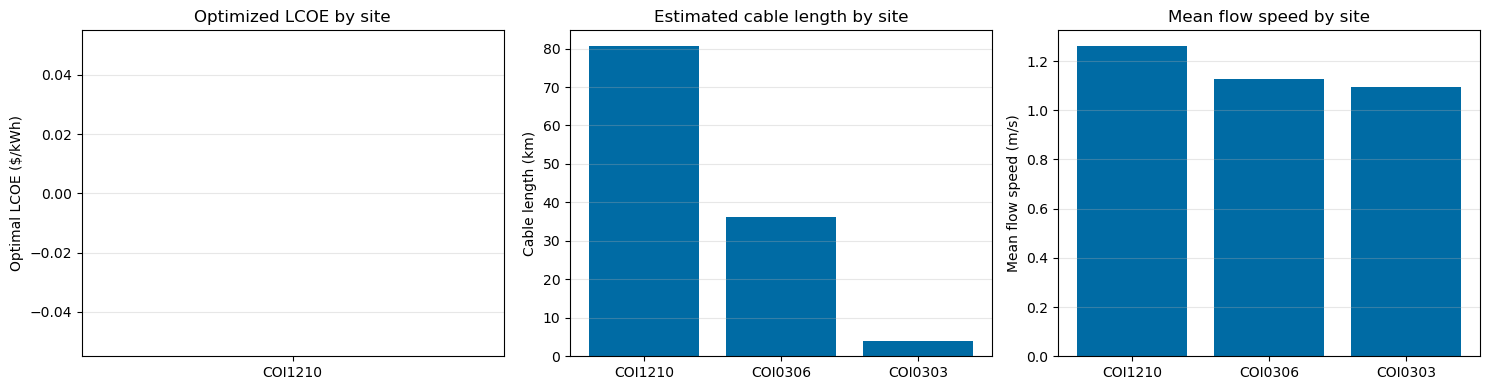

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Optimized LCOE
axs[0].bar(site_opt_df["Site"], site_opt_df["Optimal LCOE ($/kWh)"])
axs[0].set_ylabel("Optimal LCOE ($/kWh)")
axs[0].set_title("Optimized LCOE by site")
axs[0].grid(True, axis="y", alpha=0.3)

# Estimated cable length
axs[1].bar(site_opt_df["Site"], site_opt_df["Cable length (m)"] / 1000)
axs[1].set_ylabel("Cable length (km)")
axs[1].set_title("Estimated cable length by site")
axs[1].grid(True, axis="y", alpha=0.3)

# Mean flow speed
axs[2].bar(site_opt_df["Site"], site_opt_df["Mean flow speed (m/s)"])
axs[2].set_ylabel("Mean flow speed (m/s)")
axs[2].set_title("Mean flow speed by site")
axs[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()